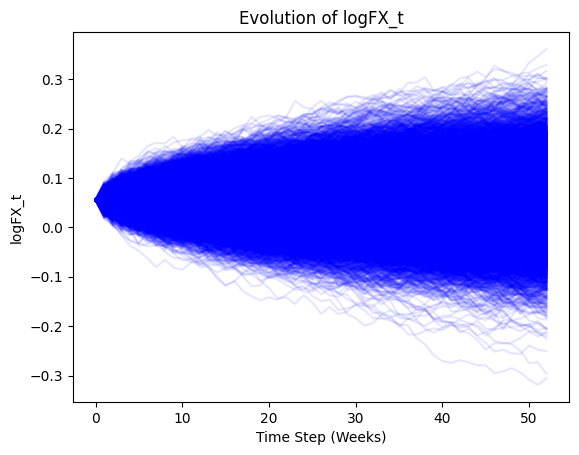

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load data
covariance_matrix = pd.read_excel('covariance_matrix.xlsx', index_col=0)
init_values = pd.read_excel('init_values.xlsx', index_col=0)

# Parameters
mu = np.array([0, 0.07 / 52, 0.06 / 52] + [0] * (len(covariance_matrix) - 3))
sigma = covariance_matrix.values
initial_values = init_values.values.flatten()

# Simulation parameters
time_steps = 52  # Weekly time steps for one year
num_simulations = 10000  # Number of simulation paths
n_assets = len(initial_values)

# Simulate paths
paths = np.zeros((num_simulations, time_steps + 1, n_assets))
paths[:, 0, :] = initial_values

for t in range(1, time_steps + 1):
    delta_x = np.random.multivariate_normal(mu, sigma, size=num_simulations)
    paths[:, t, :] = paths[:, t-1, :] + delta_x

# Extract logFX_t and visualize
log_fx_t = paths[:, :, 0]  # Assuming logFX_t is the first variable
plt.plot(range(time_steps + 1), log_fx_t.T, alpha=0.1, color='blue')
plt.title("Evolution of logFX_t")
plt.xlabel("Time Step (Weeks)")
plt.ylabel("logFX_t")
plt.show()


In [10]:
## Tilføje simulering af de manglende komponenter:
# Udtræk værdier for aktier og obligationer
log_v_us_t = paths[:, :, 1]  # Antager V_1^{US,local} er 2. kolonne
log_v_eur_t = paths[:, :, 2]  # Antager V_1^{EUR} er 3. kolonne

# Obligationspriser (eksempel: USD og EUR obligationer med 4 år tilbage)
def bond_price(yield_curve, time_to_maturity):
    """Beregn nulpunktsobligationsprisen."""
    return np.exp(-yield_curve * time_to_maturity)

z_us_4y = bond_price(paths[:, :, 9], 4)  # Antag yield_curve for USD obligation er 10. kolonne
z_eur_4y = bond_price(paths[:, :, 4], 4)  # Antag yield_curve for EUR obligation er 5. kolonne


In [11]:
## 2. Beregn og opsummer den fælles fordeling:
P1 = np.column_stack([
    paths[:, -1, 0],  # FX_1
    paths[:, -1, 1],  # V_1^{US,local}
    paths[:, -1, 2],  # V_1^{EUR}
    z_us_4y[:, -1],   # Z_1^{USD,4Y,local}
    z_eur_4y[:, -1]   # Z_1^{EUR,4Y}
])

# Beregn statistikker
mean_p1 = np.mean(P1, axis=0)
cov_p1 = np.cov(P1.T)

print("Mean of P1:", mean_p1)
print("Covariance matrix of P1:\n", cov_p1)


Mean of P1: [0.0559002  0.06978083 0.05968806 0.832643   0.91421405]
Covariance matrix of P1:
 [[ 5.92546475e-03  1.99874069e-03 -2.70654220e-04  5.85725134e-05
   5.76851721e-05]
 [ 1.99874069e-03  2.20866188e-02  1.73020621e-02 -1.37280539e-04
   4.33893224e-04]
 [-2.70654220e-04  1.73020621e-02  2.42522873e-02 -3.14080724e-04
   2.13813096e-04]
 [ 5.85725134e-05 -1.37280539e-04 -3.14080724e-04  1.61650502e-04
   5.75675972e-05]
 [ 5.76851721e-05  4.33893224e-04  2.13813096e-04  5.75675972e-05
   2.34533911e-04]]


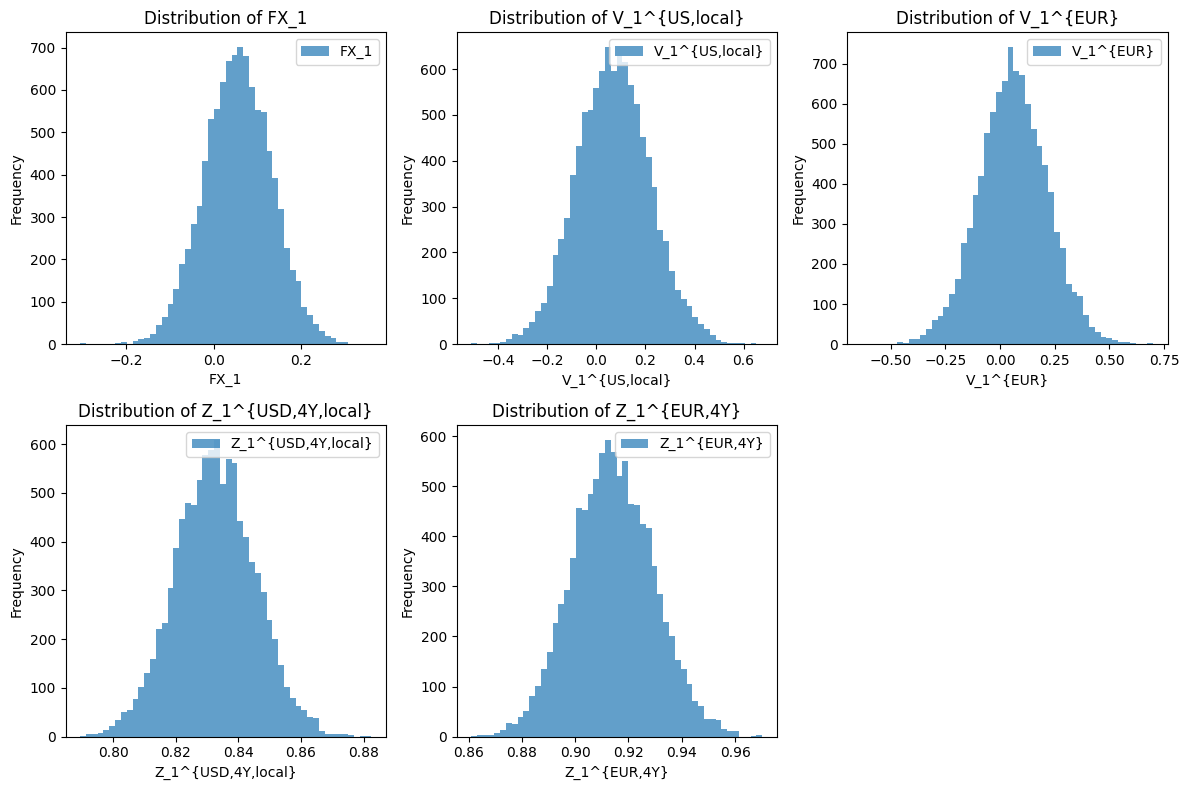

In [12]:
## Visualisering
# Histogrammer
plt.figure(figsize=(12, 8))
for i, label in enumerate(["FX_1", "V_1^{US,local}", "V_1^{EUR}", "Z_1^{USD,4Y,local}", "Z_1^{EUR,4Y}"]):
    plt.subplot(2, 3, i + 1)
    plt.hist(P1[:, i], bins=50, alpha=0.7, label=label)
    plt.title(f"Distribution of {label}")
    plt.xlabel(label)
    plt.ylabel("Frequency")
    plt.legend()
plt.tight_layout()
plt.show()
